# Hypothesis Test - Z-Test

We will use a dataset on student test performance to illustrate various types of Hypothesis Tests involving a Z Statistic. 

In [2]:
import pandas as pd
import os

student_performance_file_path = os.path.join(os.getcwd(), 'datasets', 'StudentsPerformance.csv')
student_df = pd.read_csv(student_performance_file_path)

In [7]:
student_df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


# 1-Pop T-Test Example

Assumptions: 
- Dependent Variable is continuous
- Observation data is independent 
- Sample data is approximately normal

## Research Question Example
The average student nationwide would score below a 70 in reading.  

## Check Assumptions

- The dependent variable is reading score, which is measured in points and presented as an integer. *We can still make sense of points as floats (e.g., we understand what a 72.5 score means) and so we can assume the dependent variable is continuous. 
- Observation data is of individual students and thus assumed to be independent.
- We need to check if the data is approximately normally distributed. We'll do that in two ways: graph the data for general bell shape and examine the mean and median of the data (if they are very close, this is evidence that the data is approximately normally distributed). 

66.089
66.0


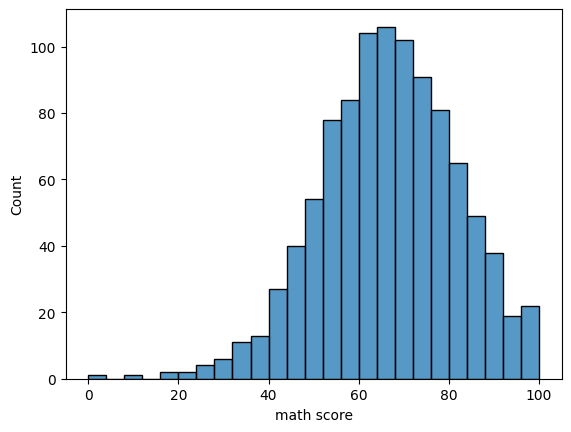

In [11]:
import seaborn as sns

sns.histplot(data=student_df, x='math score')
print(round(student_df['math score'].mean(), 3))
print(round(student_df['math score'].median(), 3))

## Hypotheses

$H_0: \mu = 70$ reading score

$H_a: \mu < 70$ reading score

## P-Value

In [18]:
from statsmodels.stats import weightstats

reading_series = student_df['reading score']
test_stat, pvalue = weightstats.ztest(
    x1=reading_series, 
    x2=None,
    value=70, 
    alternative='smaller'
)
print(f'P-value: {pvalue}')

P-value: 0.03594015171125596


## Power and Effect Size

Since we already have a sample, we know 'nobs' (number of observations). We can choose power and calculate effect size OR we can choose effect size and calculate power. We commonly choose power to be 0.8 or greater and calculate effect size. 

In [24]:
from statsmodels.stats.power import normal_power_het

effect_size_1_pop_z = normal_power_het.solve_power(
    effect_size=None, 
    nobs=len(reading_series), 
    alpha=0.05,
    power=0.9,
    alternative='smaller'
)
print(f'Effect size: {round(effect_size_1_pop_z, 3)}')

AttributeError: 'function' object has no attribute 'solve_power'

## Final Interpretation

We conducted a hypothesis test to determine if there is statistically significant evidence that all people with diabetes have less than 2 hours of physical activity per week. With a p-value of 2.18e-127, our sample suggests we do have statistically significant evidence that all people with diabetes have less than 2 hours of physical activity per week. However, with an effect size of 0.157, we observe a small effect and thus the true average of physical activity of people with diabetes is likely less than but close to 2 hours per week. 

# 2-Pop T-Test Example

Assumptions: 
- Dependent Variable is continuous
- Observation data is independent 
- Sample data is approximately normal OR n > 30
- Variance is equal between populations OR Variance is not equal between populations (Welch T-Test)

## Research Question

There is no difference in average BMI between people who do and do not have diabetes. 

## Check Assumptions

- The dependent variable is Body Mass Index (BMI), which is measured in kilograms per square meter (continuous) and presented as a float. 
- Observation data is of individual people and thus assumed to be independent.
- Our sample size is 97,297 and so is above n > 30. We can still check if the sample is normally distributed or has extreme outliers.
- We don't know that the population variance are the same, so let's examine the samples and see if we they might be. Otherwise we will assume the population variances are different.

In [41]:
diabetes_only_df = diabetes_df[diabetes_df['diagnosed_diabetes'] == 1].copy()
bmi_yes_diabetes_series = diabetes_only_df['bmi']
bmi_yes_variance = bmi_yes_diabetes_series.var()
print(f'Diabetes sample variance: {round(bmi_yes_variance, 3)}')

no_diabetes_df = diabetes_df[diabetes_df['diagnosed_diabetes'] == 0].copy()
bmi_no_diabetes_series = no_diabetes_df['bmi']
bmi_no_variance = bmi_no_diabetes_series.var()
print(f'No diabetes sample variance: {round(bmi_no_variance, 3)}')


Diabetes sample variance: 12.814
No diabetes sample variance: 12.667


These are fairly close, so we can assume the population variances are the same. Interested students can run the hypothesis test without this assumption to see what changes.

We can look at the distributions to see why variance might be assumed to be the same and see if the data is normally distributed.

<Axes: xlabel='bmi', ylabel='Count'>

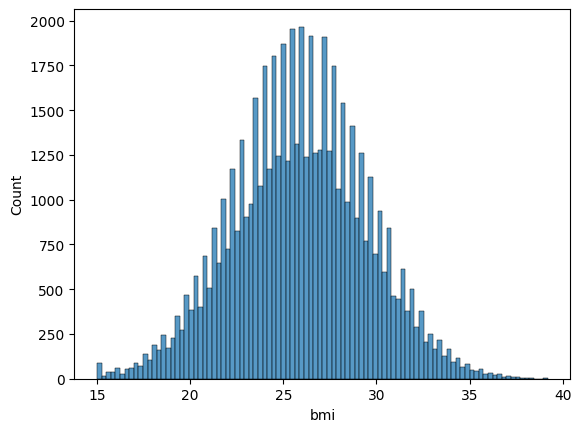

In [ ]:
sns.histplot(data=diabetes_only_df, x='bmi')

<Axes: xlabel='bmi', ylabel='Count'>

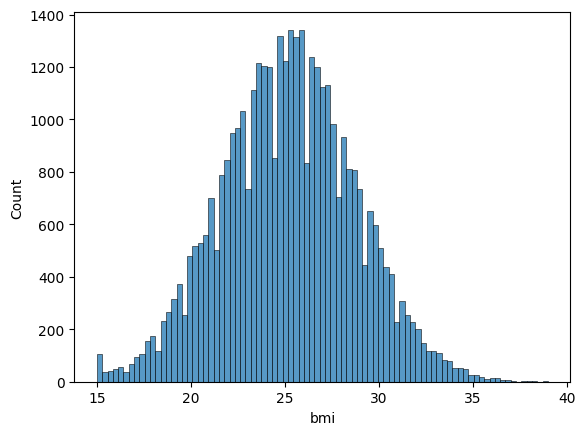

In [ ]:
sns.histplot(data=no_diabetes_df, x='bmi')

## P-Value

In [ ]:
results_2pop = stats.ttest_ind(
    bmi_yes_diabetes_series,
    bmi_no_diabetes_series, 
    equal_var=True, # This is true by default
    alternative='two-sided', # This is two-sided by default
)
print(f'P-value: {results_2pop.pvalue}')

P-value: 7.272802236405973e-203


## Power and Effect Size

In [47]:
from statsmodels.stats.power import TTestIndPower

diabetes_nobs1 = len(bmi_yes_diabetes_series)
diabetes_nobs2 = len(bmi_no_diabetes_series)
diabetes_ratio = diabetes_nobs2/diabetes_nobs1

effect_size_2_pop_t = TTestIndPower().solve_power(
    effect_size=None, 
    nobs1=diabetes_nobs1, 
    alpha=0.05,
    power=0.9,
    ratio=diabetes_ratio,
    alternative='two-sided'
)
print(f'Effect size: {round(effect_size_2_pop_t, 3)}')

Effect size: 0.021


## Final Interpretation

We conducted a hypothesis test to determine if there is statistically significant evidence that there is a difference in average BMI between people who do and do not have diabetes. With a p-value of 7.27e-203, our sample suggests we do have statistically significant evidence that there is a difference in average BMI between people who do and do not have diabetes. However, with an effect size of 0.021, we observe a very small effect and thus the true average BMI between people who do and do not have diabetes is different but very small. 

*Notice: Since we conducted a 2-tail hypothesis test, we cannot say one population's average BMI is smaller than the other. You would need to conduct the 1-tail hypothesis test to confirm which is likely smaller.*